<font face="B Mitra" size=4>
<div dir=rtl align=center>
<br>
<img src="https://aut.ac.ir/templates/tmpl_modern01/images/logo_fa.png" alt="Amirkabir University Logo" width="100">
<br>
<font size=6>
<b>پروژه دوم داده کاوی</b>
<br>
<b><font size=5> استاد درس: دکتر فاطمه شاکری</b>
<br>
<b><font size=5> گروه ۲۹</b>
<hr>
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<font size=6>
<b> معرفی مجموعه داده </b>
<br>
<p align="justify">
<font size=5>
مجموعه داده آورده شده حاوی اطلاعات آب و هوایی ۱۰ سال اخیر در یک کشور می‌باشد که به صورت روزانه و در مکان‌های مختلف جمع‌آوری شده است.

هدف ما این است که بر اساس مجموعه داده فوق، یک مدل یادگیری ماشین برای پیش‌بینی بارش ارائه دهیم که با گرفتن اطلاعات آب و هوایی یک روز مشخص، بتواند با دقت خوبی وضعیت بارش در روز آتی را مشخص کند.
</p>
</font>
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<font size=5>
<b> بارگذاری کتابخانه های موردنیاز </b>
<br>
</div>
</font>

In [501]:
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from prettytable import PrettyTable 

<font face="B Mitra">
<div dir=rtl>
<font size=5>
<b> بارگذاری مجموعه داده </b>
<br>
</div>
</font>

In [502]:
df = pd.read_csv('Dataset.csv')
df.head()

,Unnamed: 0,Date,Weather Station,Minimum Temperature,Maximum Temperature,Rainfall,Evaporation,Sunshine,Gust Trajectory,Air Velocity,...,Moisture Level at 9 AM,Moisture Level at 3 PM,Atmospheric Pressure at 9 AM,Atmospheric Pressure at 3 PM,Cloudiness at 9 AM,Cloudiness at 3 PM,Recorded Temperature at 9 AM,Recorded Temperature at 3 PM,Rain that day,Rain the day after
0,0,12/1/2008,Station 2,13.4,22.9,0.6,NaN,NaN,W,44.0,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,1,12/2/2008,Station 2,7.4,25.1,0.0,NaN,NaN,WNW,44.0,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2,12/3/2008,Station 2,12.9,25.7,0.0,NaN,NaN,WSW,46.0,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,3,12/4/2008,Station 2,9.2,28.0,0.0,NaN,NaN,NE,24.0,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,4,12/5/2008,Station 2,17.5,32.3,1.0,NaN,NaN,W,41.0,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
ستون ۱ حاوی شماره سطر داده‌ها می‌باشد. این ستون اضافه است؛ ابتدا این ستون را حذف می‌کنیم.

</p>
</font>
</div>
</font>

In [503]:
df = df.drop(df.columns[0], axis=1)
df.head()

,Date,Weather Station,Minimum Temperature,Maximum Temperature,Rainfall,Evaporation,Sunshine,Gust Trajectory,Air Velocity,Gust Trajectory at 9 AM,...,Moisture Level at 9 AM,Moisture Level at 3 PM,Atmospheric Pressure at 9 AM,Atmospheric Pressure at 3 PM,Cloudiness at 9 AM,Cloudiness at 3 PM,Recorded Temperature at 9 AM,Recorded Temperature at 3 PM,Rain that day,Rain the day after
0,12/1/2008,Station 2,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,12/2/2008,Station 2,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,12/3/2008,Station 2,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,12/4/2008,Station 2,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,12/5/2008,Station 2,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


<font face="B Mitra">
<div dir=rtl>
<font size=6>
<b> پیش پردازش </b>
<p align="justify">
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<font size=5>
<b> نمایش اطلاعات مجموعه داده </b>
<br>
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
در این قسمت ابعاد مجموعه داده و مقادیر آماری داده‌های عددی را به نمایش می‌گذاریم.
</p>
</font>
</div>
</font>

In [504]:
df.shape

(145460, 23)

In [505]:
df.describe()

,Minimum Temperature,Maximum Temperature,Rainfall,Evaporation,Sunshine,Air Velocity,Air Velocity at 9 AM,Air Velocity at 3 PM,Moisture Level at 9 AM,Moisture Level at 3 PM,Atmospheric Pressure at 9 AM,Atmospheric Pressure at 3 PM,Cloudiness at 9 AM,Cloudiness at 3 PM,Recorded Temperature at 9 AM,Recorded Temperature at 3 PM
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


<font face="B Mitra">
<div dir=rtl>
<font size=5>
<b> تبدیل داده‌های اسمی به داده‌های عددی </b>
<br>
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
در این قسمت، ابتدا نوع مقادیری که هر feature گرفته است را مشخص می‌کنیم؛
سپس مقادیر اسمی را به مقادیر عددی تبدیل می‌کنیم.
</p>
</font>
</div>
</font>

In [506]:
df.dtypes

Date                                str
Weather Station                     str
Minimum Temperature             float64
Maximum Temperature             float64
Rainfall                        float64
Evaporation                     float64
Sunshine                        float64
Gust Trajectory                     str
Air Velocity                    float64
Gust Trajectory at  9 AM            str
Gust Trajectory at  3 PM            str
Air Velocity at  9 AM           float64
Air Velocity at  3 PM           float64
Moisture Level at 9 AM          float64
Moisture Level at 3 PM          float64
Atmospheric Pressure at 9 AM    float64
Atmospheric Pressure at 3 PM    float64
Cloudiness at 9 AM              float64
Cloudiness at 3 PM              float64
Recorded Temperature at 9 AM    float64
Recorded Temperature at 3 PM    float64
Rain that day                       str
Rain the day after                  str
dtype: object

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
ویژگی Date را به داده‌های عددی تبدیل می‌کنیم و در سه ستون با نام‌های Year و Month و Weekday ذخیره می‌کنیم.
<br>
در پایان نیز ستون Date را حذف می‌کنیم.
</p>
</font>
</div>
</font>

In [507]:
df['Date'] = pd.to_datetime(df['Date'], format = 'mixed')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Weekday'] = df['Date'].dt.weekday

df = df.drop('Date', axis=1)
df.head()

,Weather Station,Minimum Temperature,Maximum Temperature,Rainfall,Evaporation,Sunshine,Gust Trajectory,Air Velocity,Gust Trajectory at 9 AM,Gust Trajectory at 3 PM,...,Atmospheric Pressure at 3 PM,Cloudiness at 9 AM,Cloudiness at 3 PM,Recorded Temperature at 9 AM,Recorded Temperature at 3 PM,Rain that day,Rain the day after,Year,Month,Weekday
0,Station 2,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,...,1007.1,8.0,NaN,16.9,21.8,No,No,2008,12,0
1,Station 2,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,1007.8,NaN,NaN,17.2,24.3,No,No,2008,12,1
2,Station 2,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,...,1008.7,NaN,2.0,21.0,23.2,No,No,2008,12,2
3,Station 2,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,...,1012.8,NaN,NaN,18.1,26.5,No,No,2008,12,3
4,Station 2,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,...,1006.0,7.0,8.0,17.8,29.7,No,No,2008,12,4


<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
ویژگی Weather Station را به داده‌های عددی تبدیل می‌کنیم و در ستونی با نام Weather Station_Encoded ذخیره می‌کنیم.
<br>
در پایان نیز ستون Weather Station را حذف می‌کنیم.
</p>
</font>
</div>
</font>

In [508]:
def extract_station_number(text):
  return int(text.split()[1])

df['Weather Station_Encoded'] = df['Weather Station'].apply(extract_station_number)

df = df.drop('Weather Station', axis=1)
df.head()

,Minimum Temperature,Maximum Temperature,Rainfall,Evaporation,Sunshine,Gust Trajectory,Air Velocity,Gust Trajectory at 9 AM,Gust Trajectory at 3 PM,Air Velocity at 9 AM,...,Cloudiness at 9 AM,Cloudiness at 3 PM,Recorded Temperature at 9 AM,Recorded Temperature at 3 PM,Rain that day,Rain the day after,Year,Month,Weekday,Weather Station_Encoded
0,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,...,8.0,NaN,16.9,21.8,No,No,2008,12,0,2
1,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,...,NaN,NaN,17.2,24.3,No,No,2008,12,1,2
2,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,...,NaN,2.0,21.0,23.2,No,No,2008,12,2,2
3,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,...,NaN,NaN,18.1,26.5,No,No,2008,12,3,2
4,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,...,7.0,8.0,17.8,29.7,No,No,2008,12,4,2


<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
سه ویژگی Gust Trajectory، Gust Trajectory at  9 AM و Gust Trajectory at  3 PM را به داده‌های عددی تبدیل می‌کنیم.
<br>
در پایان نیز سه ستون Gust Trajectory، Gust Trajectory at  9 AM و Gust Trajectory at  3 PM را حذف می‌کنیم.

</p>
</font>
</div>
</font>

In [509]:
directions = [
    'N', 'NNE', 'NE', 'ENE',
    'E', 'ESE', 'SE', 'SSE',
    'S', 'SSW', 'SW', 'WSW',
    'W', 'WNW', 'NW', 'NNW',
]

# Angles are in radians
encoder_dict = {dir: (2 * np.pi * i / 16) for i, dir in enumerate(directions)}


df['Gust_Angle'] = df['Gust Trajectory'].map(encoder_dict)
df['Gust_Sine'] = np.sin(df['Gust_Angle'])
df['Gust_Cosine'] = np.cos(df['Gust_Angle'])
df.drop(columns=['Gust_Angle'], inplace=True)

df['Gust_Angle_9'] = df['Gust Trajectory at  9 AM'].map(encoder_dict)
df['Gust_9_Sine'] = np.sin(df['Gust_Angle_9'])
df['Gust_9_Cosine'] = np.cos(df['Gust_Angle_9'])
df.drop(columns=['Gust_Angle_9'], inplace=True)

df['Gust_Angle_3'] = df['Gust Trajectory at  3 PM'].map(encoder_dict)
df['Gust_3_Sine'] = np.sin(df['Gust_Angle_3'])
df['Gust_3_Cosine'] = np.cos(df['Gust_Angle_3'])
df.drop(columns=['Gust_Angle_3'], inplace=True)


df = df.drop('Gust Trajectory', axis=1)
df = df.drop('Gust Trajectory at  9 AM', axis=1)
df = df.drop('Gust Trajectory at  3 PM', axis=1)
df.head()

,Minimum Temperature,Maximum Temperature,Rainfall,Evaporation,Sunshine,Air Velocity,Air Velocity at 9 AM,Air Velocity at 3 PM,Moisture Level at 9 AM,Moisture Level at 3 PM,...,Year,Month,Weekday,Weather Station_Encoded,Gust_Sine,Gust_Cosine,Gust_9_Sine,Gust_9_Cosine,Gust_3_Sine,Gust_3_Cosine
0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,...,2008,12,0,2,-1.000000,-1.836970e-16,-1.000000,-1.836970e-16,-0.923880,3.826834e-01
1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,...,2008,12,1,2,-0.923880,3.826834e-01,-0.382683,9.238795e-01,-0.923880,-3.826834e-01
2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,...,2008,12,2,2,-0.923880,-3.826834e-01,-1.000000,-1.836970e-16,-0.923880,-3.826834e-01
3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,...,2008,12,3,2,0.707107,7.071068e-01,0.707107,-7.071068e-01,1.000000,6.123234e-17
4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0,...,2008,12,4,2,-1.000000,-1.836970e-16,0.923880,3.826834e-01,-0.707107,7.071068e-01


<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
ویژگی‌های Rain that day و Rain the day after را به داده‌های عددی تبدیل می‌کنیم و ستون‌های اولیه را حذف می‌کنیم.
</p>
</font>
</div>
</font>

In [510]:
df['Rain that day_Encoded'] = df['Rain that day'].map({'Yes': 1, 'No': 0})
df['Rain the day after_Encoded'] = df['Rain the day after'].map({'Yes': 1, 'No': 0})

df = df.drop('Rain that day', axis=1)
df = df.drop('Rain the day after', axis=1)
df.head()

,Minimum Temperature,Maximum Temperature,Rainfall,Evaporation,Sunshine,Air Velocity,Air Velocity at 9 AM,Air Velocity at 3 PM,Moisture Level at 9 AM,Moisture Level at 3 PM,...,Weekday,Weather Station_Encoded,Gust_Sine,Gust_Cosine,Gust_9_Sine,Gust_9_Cosine,Gust_3_Sine,Gust_3_Cosine,Rain that day_Encoded,Rain the day after_Encoded
0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,...,0,2,-1.000000,-1.836970e-16,-1.000000,-1.836970e-16,-0.923880,3.826834e-01,0.0,0.0
1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,...,1,2,-0.923880,3.826834e-01,-0.382683,9.238795e-01,-0.923880,-3.826834e-01,0.0,0.0
2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,...,2,2,-0.923880,-3.826834e-01,-1.000000,-1.836970e-16,-0.923880,-3.826834e-01,0.0,0.0
3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,...,3,2,0.707107,7.071068e-01,0.707107,-7.071068e-01,1.000000,6.123234e-17,0.0,0.0
4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0,...,4,2,-1.000000,-1.836970e-16,0.923880,3.826834e-01,-0.707107,7.071068e-01,0.0,0.0


<font face="B Mitra">
<div dir=rtl>
<font size=5>
<b> بررسی همبستگی ویژگی‌ها </b>
<br>
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
برای تشخیص میزان همبستگی داده‌ها به یکدیگر، نمودار Correlation Heatmap را رسم می‌کنیم.

</p>
</font>
</div>
</font>

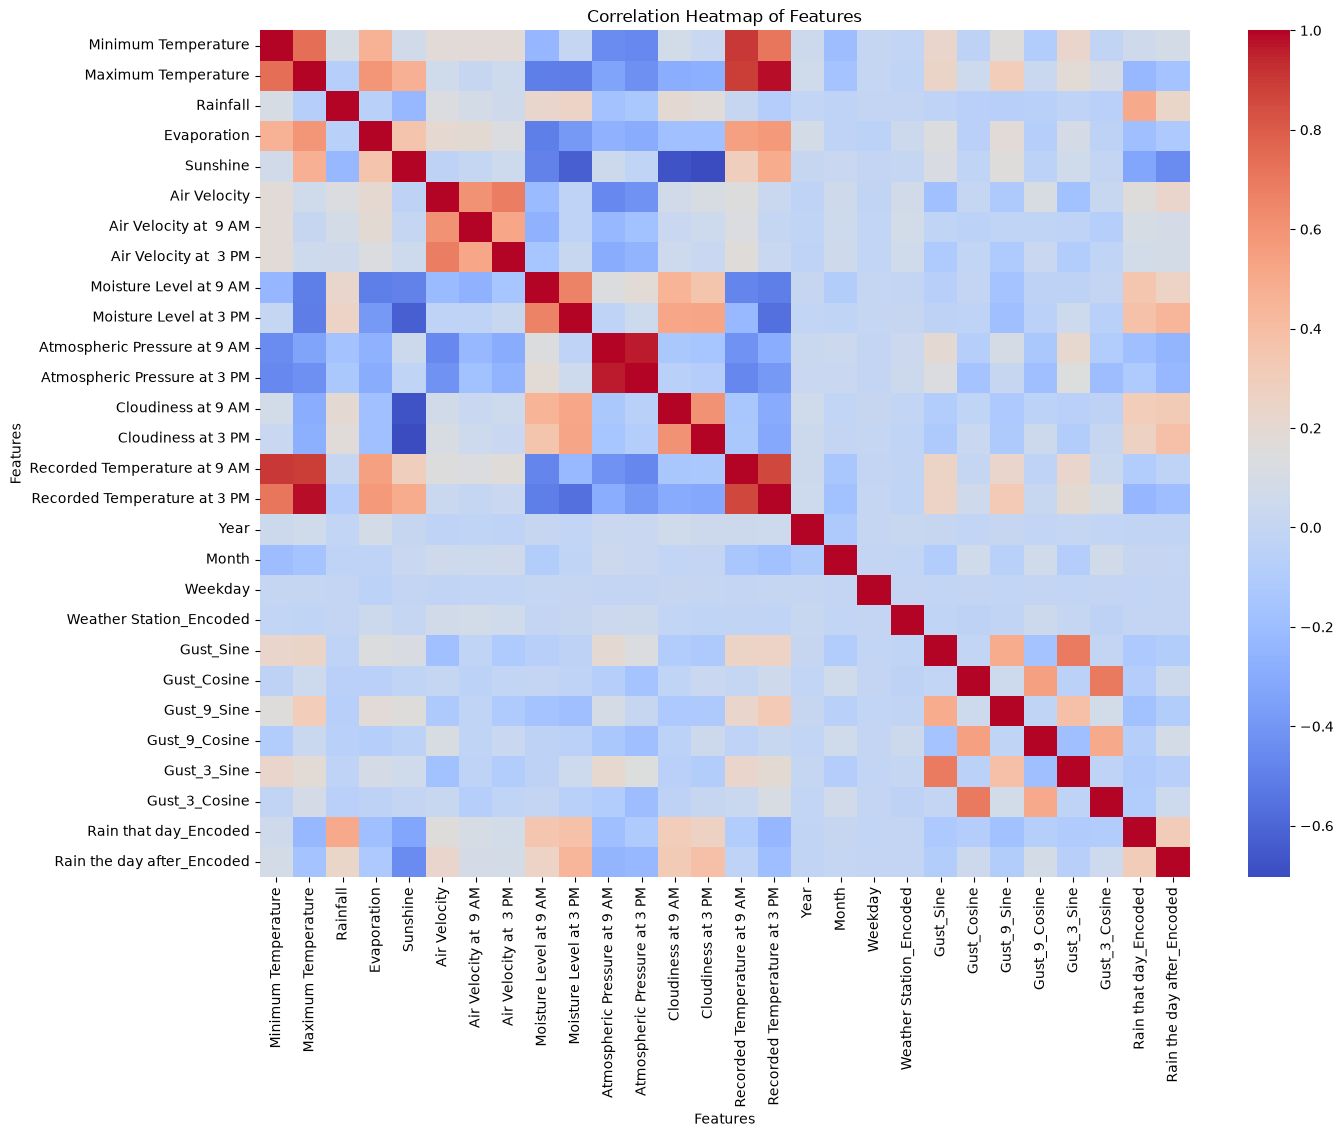

In [511]:
# Selecting columns that have numeric values
numerical_cols = df.select_dtypes(include=[np.number])

plt.figure(figsize=(15, 11))
correlation_matrix = numerical_cols.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm')

plt.xlabel('Features')
plt.ylabel('Features')
plt.title('Correlation Heatmap of Features')

plt.show()

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
در حالی که مدل Decision Tree می‌تواند ویژگی‌های با وابستگی زیاد را به خوبی کنترل کند؛ اما برای استفاده از دو مدل KNN و SVM، باید این وابستگی‌ها به گونه‌ای با یکدیگر ترکیب کنیم که در عین از بین بردن این وابستگی‌ها، اطلاعات موجود در این ویژگی‌ها از بین نرود.
<br><br>
برای رفع وابستگی دو ویژگی Recorded Temperature at 9 AM و Recorded Temperature at 3 PM، یک ویژگی جدید ایجاد می‌کنیم :
<br>
Diurnal_Change : این ویژگی روند گرمایش یا سرمایش در طول روز را نشان می‌دهد

</p>
</font>
</div>
</font>

In [512]:
df["Diurnal_Change"] = df["Recorded Temperature at 3 PM"] - df["Recorded Temperature at 9 AM"]

df = df.drop('Recorded Temperature at 9 AM', axis=1)
df = df.drop('Recorded Temperature at 3 PM', axis=1)
df.head()

,Minimum Temperature,Maximum Temperature,Rainfall,Evaporation,Sunshine,Air Velocity,Air Velocity at 9 AM,Air Velocity at 3 PM,Moisture Level at 9 AM,Moisture Level at 3 PM,...,Weather Station_Encoded,Gust_Sine,Gust_Cosine,Gust_9_Sine,Gust_9_Cosine,Gust_3_Sine,Gust_3_Cosine,Rain that day_Encoded,Rain the day after_Encoded,Diurnal_Change
0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,...,2,-1.000000,-1.836970e-16,-1.000000,-1.836970e-16,-0.923880,3.826834e-01,0.0,0.0,4.9
1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,...,2,-0.923880,3.826834e-01,-0.382683,9.238795e-01,-0.923880,-3.826834e-01,0.0,0.0,7.1
2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,...,2,-0.923880,-3.826834e-01,-1.000000,-1.836970e-16,-0.923880,-3.826834e-01,0.0,0.0,2.2
3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,...,2,0.707107,7.071068e-01,0.707107,-7.071068e-01,1.000000,6.123234e-17,0.0,0.0,8.4
4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0,...,2,-1.000000,-1.836970e-16,0.923880,3.826834e-01,-0.707107,7.071068e-01,0.0,0.0,11.9


<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
با توجه به نمودار دو ویژگی Atmospheric Pressure at 9 AM و Atmospheric Pressure at 3 PM همبستگی بسیار زیادی با یکدیگر دارند. که این موضوع نشان دهنده آن است که فشار هوا در طول روز تغییر زیادی نکرده است. در نتیجه میانگین این دو ویژگی را در ستونی به نام Average Atmospheric Pressure ذخیره کرده و این دو ویژگی را حذف می‌کنیم.

</p>
</font>
</div>
</font>

In [513]:
def calculate_average(row):
    pressure_9am = row['Atmospheric Pressure at 9 AM']
    pressure_3pm = row['Atmospheric Pressure at 3 PM']
    if pd.isna(pressure_9am) and pd.isna(pressure_3pm):
        return None
    elif pd.isna(pressure_9am):
        return pressure_3pm
    elif pd.isna(pressure_3pm):
        return pressure_9am
    else:
        return (pressure_9am + pressure_3pm) / 2
    

df['Average Atmospheric Pressure'] = df.apply(calculate_average, axis=1)
df = df.drop('Atmospheric Pressure at 9 AM', axis=1)
df = df.drop('Atmospheric Pressure at 3 PM', axis=1)
df.head()

,Minimum Temperature,Maximum Temperature,Rainfall,Evaporation,Sunshine,Air Velocity,Air Velocity at 9 AM,Air Velocity at 3 PM,Moisture Level at 9 AM,Moisture Level at 3 PM,...,Gust_Sine,Gust_Cosine,Gust_9_Sine,Gust_9_Cosine,Gust_3_Sine,Gust_3_Cosine,Rain that day_Encoded,Rain the day after_Encoded,Diurnal_Change,Average Atmospheric Pressure
0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,...,-1.000000,-1.836970e-16,-1.000000,-1.836970e-16,-0.923880,3.826834e-01,0.0,0.0,4.9,1007.40
1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,...,-0.923880,3.826834e-01,-0.382683,9.238795e-01,-0.923880,-3.826834e-01,0.0,0.0,7.1,1009.20
2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,...,-0.923880,-3.826834e-01,-1.000000,-1.836970e-16,-0.923880,-3.826834e-01,0.0,0.0,2.2,1008.15
3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,...,0.707107,7.071068e-01,0.707107,-7.071068e-01,1.000000,6.123234e-17,0.0,0.0,8.4,1015.20
4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0,...,-1.000000,-1.836970e-16,0.923880,3.826834e-01,-0.707107,7.071068e-01,0.0,0.0,11.9,1008.40


<font face="B Mitra">
<div dir=rtl>
<font size=5>
<b> رفع نقص داده‌ها </b>
<br>
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
ابتدا تعداد مقادیر خالی هر feature را چاپ می‌کنیم.

</p>
</font>
</div>
</font>

In [514]:
df.isnull().sum()

Minimum Temperature              1485
Maximum Temperature              1261
Rainfall                         3261
Evaporation                     62790
Sunshine                        69835
Air Velocity                    10263
Air Velocity at  9 AM            1767
Air Velocity at  3 PM            3062
Moisture Level at 9 AM           2654
Moisture Level at 3 PM           4507
Cloudiness at 9 AM              55888
Cloudiness at 3 PM              59358
Year                                0
Month                               0
Weekday                             0
Weather Station_Encoded             0
Gust_Sine                       10326
Gust_Cosine                     10326
Gust_9_Sine                     10566
Gust_9_Cosine                   10566
Gust_3_Sine                      4228
Gust_3_Cosine                    4228
Rain that day_Encoded            3261
Rain the day after_Encoded       3267
Diurnal_Change                   4247
Average Atmospheric Pressure    14804
dtype: int64

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
دو ستون Rain that day_Encoded و Rain the day after_Encoded لیبل‌های اصلی مجموعه داده هستند. 
بهتر است تغییری رو آن‌ها اعمال نکنیم و  داده‌هایی که این ستون‌شان خالی است را حذف کنیم.

</p>
</font>
</div>
</font>

In [515]:
df = df.dropna(subset=['Rain that day_Encoded'])
df = df.dropna(subset=['Rain the day after_Encoded'])

print(df['Rain that day_Encoded'].isnull().sum())
print(df['Rain the day after_Encoded'].isnull().sum())

0
0


<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
مشاهده می‌شود که دو ویژگی Evaporation و Sunshine تعداد مقادیر خالی بسیار زیادی دارند. (این دو ویژگی تقریبا برای نیمی از داده‌ها مقدار ندارند.)
همچنین این دو ویژگی تا حدودی با ویژگی‌های مرتبط با دما در ارتباط هستند
پس این دو ستون را حذف می‌کنیم.

</p>
</font>
</div>
</font>

In [516]:
df = df.drop('Evaporation', axis=1)
df = df.drop('Sunshine', axis=1)

df.head()

,Minimum Temperature,Maximum Temperature,Rainfall,Air Velocity,Air Velocity at 9 AM,Air Velocity at 3 PM,Moisture Level at 9 AM,Moisture Level at 3 PM,Cloudiness at 9 AM,Cloudiness at 3 PM,...,Gust_Sine,Gust_Cosine,Gust_9_Sine,Gust_9_Cosine,Gust_3_Sine,Gust_3_Cosine,Rain that day_Encoded,Rain the day after_Encoded,Diurnal_Change,Average Atmospheric Pressure
0,13.4,22.9,0.6,44.0,20.0,24.0,71.0,22.0,8.0,NaN,...,-1.000000,-1.836970e-16,-1.000000,-1.836970e-16,-0.923880,3.826834e-01,0.0,0.0,4.9,1007.40
1,7.4,25.1,0.0,44.0,4.0,22.0,44.0,25.0,NaN,NaN,...,-0.923880,3.826834e-01,-0.382683,9.238795e-01,-0.923880,-3.826834e-01,0.0,0.0,7.1,1009.20
2,12.9,25.7,0.0,46.0,19.0,26.0,38.0,30.0,NaN,2.0,...,-0.923880,-3.826834e-01,-1.000000,-1.836970e-16,-0.923880,-3.826834e-01,0.0,0.0,2.2,1008.15
3,9.2,28.0,0.0,24.0,11.0,9.0,45.0,16.0,NaN,NaN,...,0.707107,7.071068e-01,0.707107,-7.071068e-01,1.000000,6.123234e-17,0.0,0.0,8.4,1015.20
4,17.5,32.3,1.0,41.0,7.0,20.0,82.0,33.0,7.0,8.0,...,-1.000000,-1.836970e-16,0.923880,3.826834e-01,-0.707107,7.071068e-01,0.0,0.0,11.9,1008.40


<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
دو ستون Cloudiness at 9 AM/3 PM تعداد مقادیر خالی زیادی دارند؛ اما با توجه به ماهیت مسئله، به نظر می‌رسد که این دو ستون در تعیین لیبل داده‌ها تاثیرگذار باشند. پس از حذف این دو ستون صرف نظر می‌کنیم.

</p>
</font>
</div>
</font>

In [517]:
print("Percentage of empty data in 'Cloudiness at 9 AM' column:", (df['Cloudiness at 9 AM'].isnull().sum() / len(df)) * 100)
print("Percentage of empty data in 'Cloudiness at 3 PM' column:", (df['Cloudiness at 3 PM'].isnull().sum() / len(df)) * 100)

Percentage of empty data in 'Cloudiness at 9 AM' column: 37.37916142825687
Percentage of empty data in 'Cloudiness at 3 PM' column: 39.84316733789341


<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
سایر داده‌های خالی باقی مانده را با میانه‌شان در همان ستون پر می‌کنیم.

</p>
</font>
</div>
</font>

In [518]:
df = df.fillna(df.median())

df.isnull().sum()

Minimum Temperature             0
Maximum Temperature             0
Rainfall                        0
Air Velocity                    0
Air Velocity at  9 AM           0
Air Velocity at  3 PM           0
Moisture Level at 9 AM          0
Moisture Level at 3 PM          0
Cloudiness at 9 AM              0
Cloudiness at 3 PM              0
Year                            0
Month                           0
Weekday                         0
Weather Station_Encoded         0
Gust_Sine                       0
Gust_Cosine                     0
Gust_9_Sine                     0
Gust_9_Cosine                   0
Gust_3_Sine                     0
Gust_3_Cosine                   0
Rain that day_Encoded           0
Rain the day after_Encoded      0
Diurnal_Change                  0
Average Atmospheric Pressure    0
dtype: int64

<font face="B Mitra">
<div dir=rtl>
<font size=5>
<b> کنترل داده‌های پرت </b>
<br>
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
همان طور که در نمودار پایین مشخص است، توزیع مقادیر ستون Rainfall به شدت به سمت راست چوله است. 
(بیشترین مقادیر این ستون در اطراف ۰ متمرکز هستند. به گونه‌ای که میانه این ستون برابر صفر است.)
<br>
برای حل کردن این مشکل، از روش Winsorization استفاده کرده و مقدار داده‌هایی که بالای صدک ۸۰ قرار می‌گیرند را برابر صدک ۸۰ قرار می‌دهیم.
</p>
</font>
</div>
</font>

Minimum Rainfall: 0.0
Maximum Rainfall: 371.0
Median Rainfall: 0.0


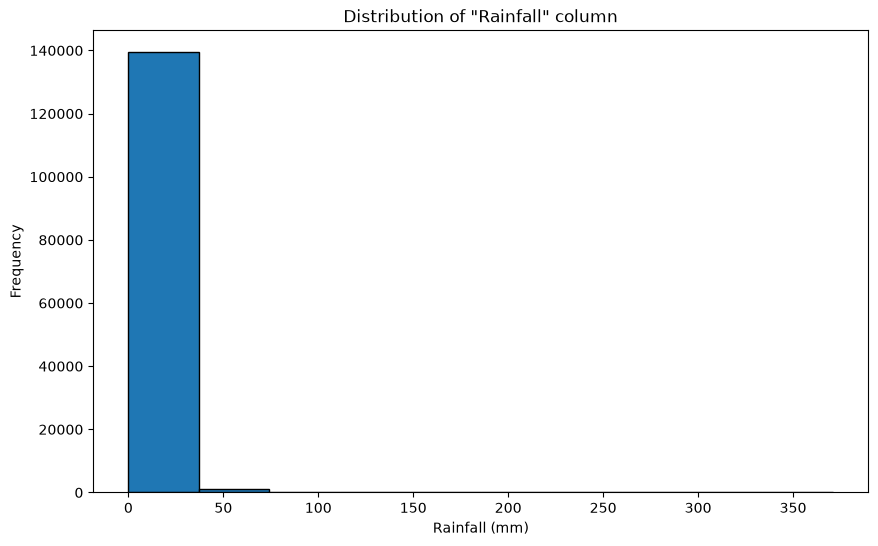

In [519]:
print("Minimum Rainfall:", df['Rainfall'].min())
print("Maximum Rainfall:", df['Rainfall'].max())
print("Median Rainfall:", df['Rainfall'].median())

plt.figure(figsize=(10, 6))
plt.hist(df['Rainfall'], edgecolor='black')

plt.title('Distribution of "Rainfall" column')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')

plt.show()

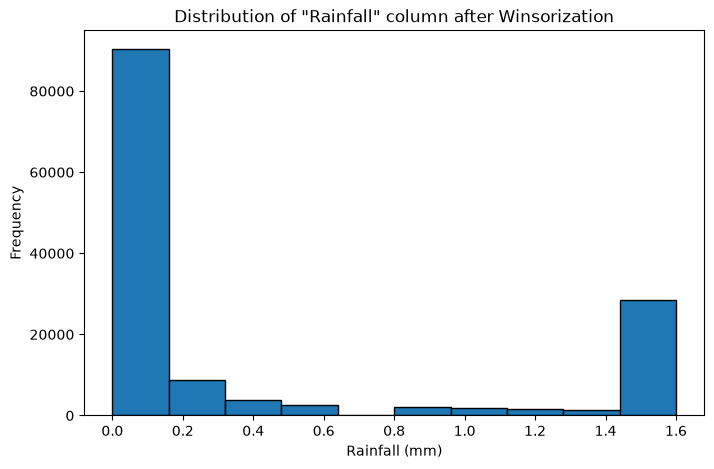

In [520]:
df['Rainfall'] = stats.mstats.winsorize(df['Rainfall'], limits=[0, 0.2])

plt.figure(figsize=(8, 5))
plt.hist(df['Rainfall'], edgecolor='black')

plt.title('Distribution of "Rainfall" column after Winsorization')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')

plt.show()

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
در این قسمت برای کارکرد بهتر مدل‌ها، با استفاده از IQR، کران بالا(upper_bound) و کران پایین(lower_bound) هر ستون را محاسبه می‌کنیم و داده‌هایی که خارج از این دو کران هستند را برابر کران نزدیک‌تر مقداردهی می‌کنیم.

</p>
</font>
</div>
</font>

In [521]:
for col in df.select_dtypes(include=[np.number]):
    if col == 'Rain that day_Encoded' or col == 'Rain the day after_Encoded':
        continue
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR

    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

d:\my_codes\dm-project-2\myvenv\Lib\site-packages\numpy\lib\_function_base_impl.py:4798: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
d:\my_codes\dm-project-2\myvenv\Lib\site-packages\numpy\lib\_function_base_impl.py:4798: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


<font face="B Mitra">
<div dir=rtl>
<font size=5>
<b> بررسی نحوه توزیع فیچر‌ها </b>
<br>
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
توزیع ستون Rainfall به دلیل اصلاحی که روی مقادیر آن انجام دادیم به شکلی نامتقارن تبدیل شده است.
<br>
توزیع ستون‌های مربوط به تاریخ(Year, Month, Weekday) با توجه به گسسته بودنشان به این شکل درآمده است.
<br>
ستون‌هایی که به شکل باینری مقداردهی شده‌اند، در نمودار به صورت دو تکه کاملا جدا از هم ظاهر شده‌اند.

</p>
</font>
</div>
</font>

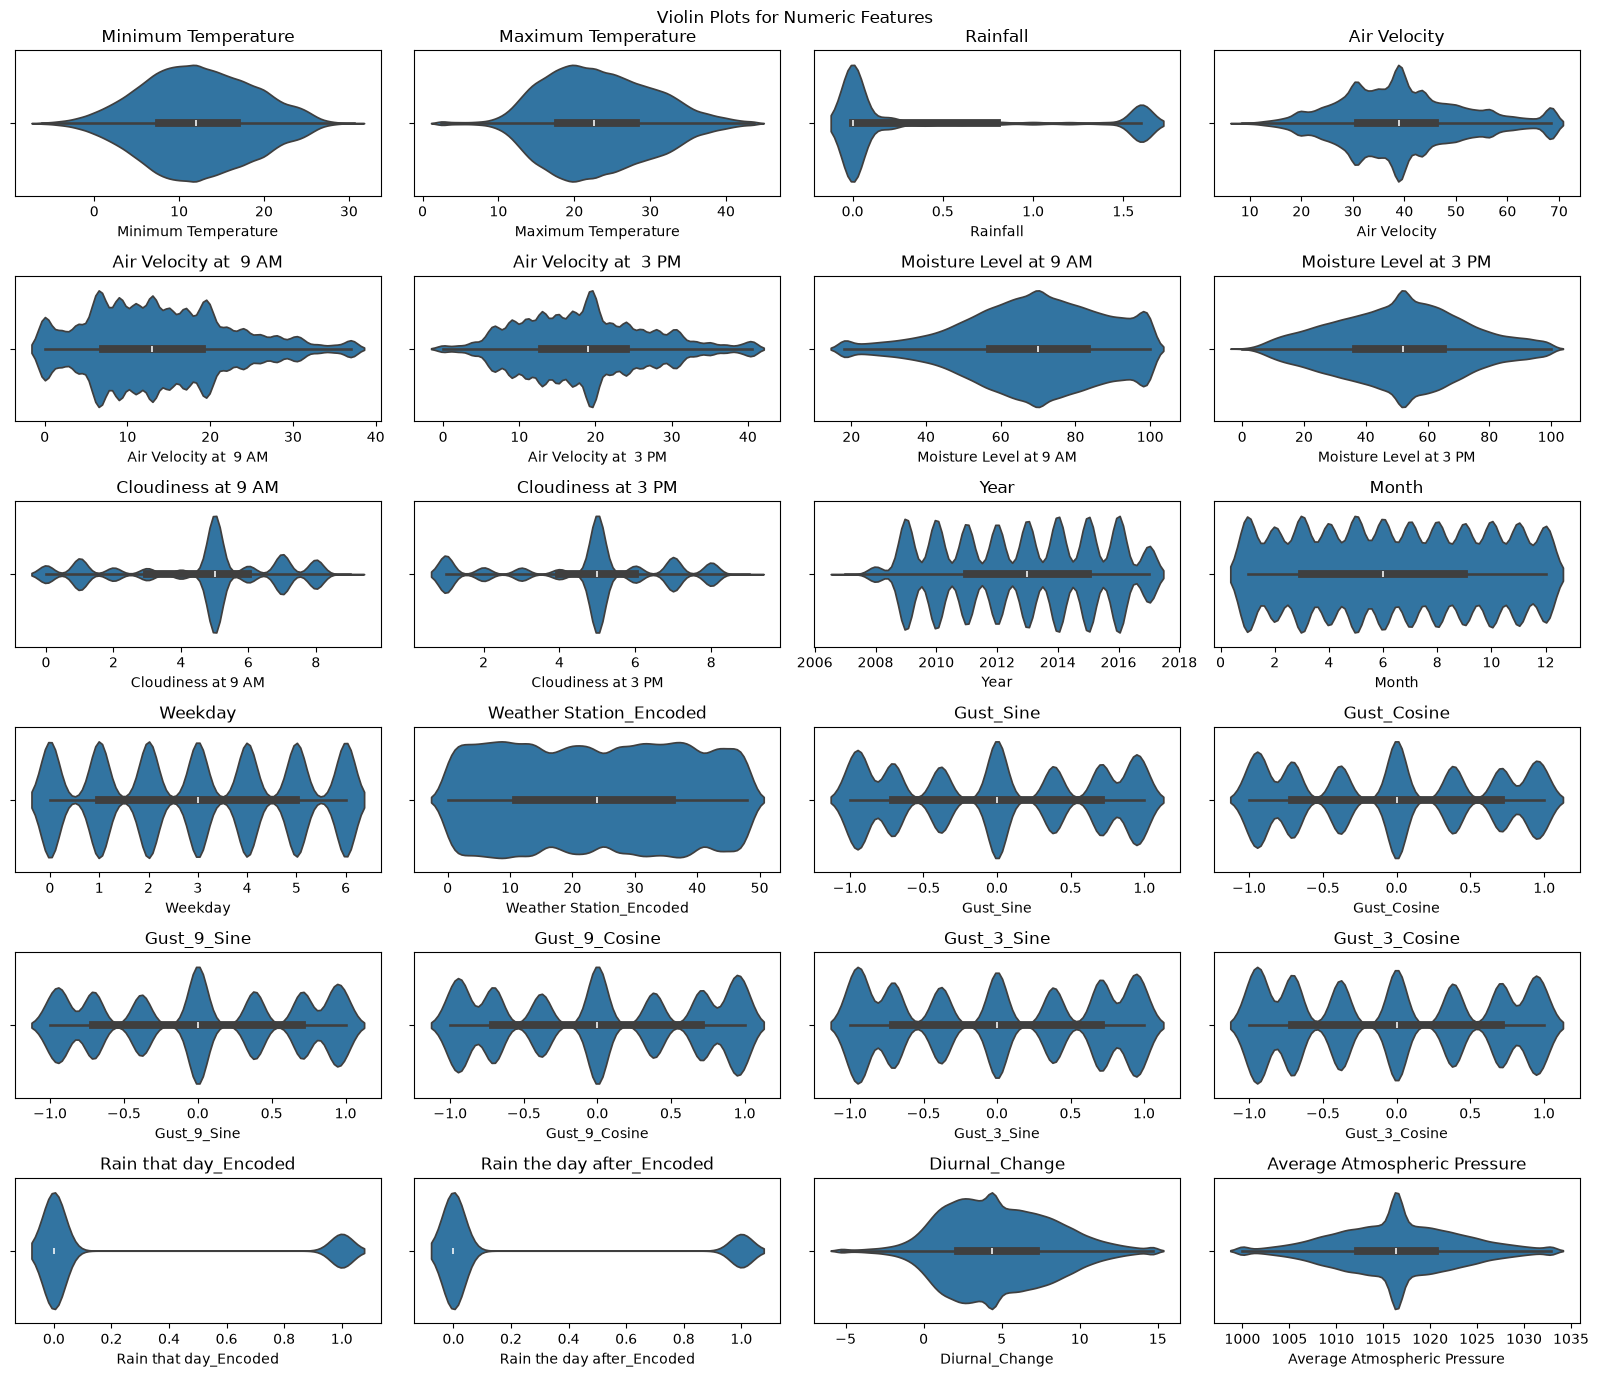

In [522]:
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(16, 14))

ax_idx = 0
for col in df.select_dtypes(include=[np.number]):
    sns.violinplot(x=col, data=df, ax=axes.flat[ax_idx])
    axes.flat[ax_idx].set_title(col)
    ax_idx += 1

fig.suptitle('Violin Plots for Numeric Features')
plt.tight_layout()

plt.show()

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
ستون Rain the day after_Encoded در واقع ستونی است که می‌بایست پیش‌بینی شود. به همین خاطر این ستون را از باقی داده‌ها جدا می‌کنیم. 
<br>
مقادیر این ستون را به y و باقی مقادیر را به x ها می‌دهیم.

</p>
</font>
</div>
</font>

In [523]:
x = df.drop(columns=["Rain the day after_Encoded"])
y = df["Rain the day after_Encoded"]

<font face="B Mitra">
<div dir=rtl>
<font size=5>
<b> تقسیم داده‌ها به دو قسمت آموزشی و آزمایشی </b>
<br>
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
۱۰.۰۰۰ داده را به عنوان داده آزمایشی و بقیه داده‌ها را به عنوان داده آموزشی در نظر می‌گیریم.

</p>
</font>
</div>
</font>

In [524]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=10000, random_state=42, stratify=y
)

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

x_train shape: (130787, 23)
x_test shape: (10000, 23)


<font face="B Mitra">
<div dir=rtl>
<font size=5>
<b> ایجاد توازن در کلاس‌ها </b>
<br>
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
همانطور که مشاهده می‌شود دو کلاس مجوعه داده متوازن نیستند و نسبت داده‌های دو کلاس، تقریبا به صورت ۳ به ۱ است.
<br>
بنابراین با استفاده از روش undersampling، دو کلاس را متوازن می‌کنیم.

</p>
</font>
</div>
</font>

In [525]:
print(len(y))
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

140787
Rain the day after_Encoded
0.0    109586
1.0     31201
Name: count, dtype: int64
Rain the day after_Encoded
0.0    77.838153
1.0    22.161847
Name: proportion, dtype: float64


In [526]:
df_train_combined = pd.concat([x_train, y_train], axis=1)

df_majority = df_train_combined[df_train_combined["Rain the day after_Encoded"] == 0]
df_minority = df_train_combined[df_train_combined["Rain the day after_Encoded"] == 1]

class_counts = df_train_combined["Rain the day after_Encoded"].value_counts()
desired_class_size = min(class_counts)

# Undersample the majority training class
df_majority_undersampled = resample(
    df_majority,
    n_samples=desired_class_size,
    replace=False,
    random_state=42,
)

df_train_balanced = pd.concat([df_majority_undersampled, df_minority], ignore_index=True).sample(frac=1, random_state=42)

y_train_balanced = df_train_balanced["Rain the day after_Encoded"]
x_train_balanced = df_train_balanced.drop(columns=["Rain the day after_Encoded"])


print(f"Balanced training samples: {len(df_train_balanced)}")
print(y_train_balanced.value_counts())
print(y_train_balanced.value_counts(normalize=True) * 100)

Balanced training samples: 57970
Rain the day after_Encoded
1.0    28985
0.0    28985
Name: count, dtype: int64
Rain the day after_Encoded
1.0    50.0
0.0    50.0
Name: proportion, dtype: float64


<font face="B Mitra">
<div dir=rtl>
<font size=5>
<b> مقیاس‌بندی ویژگی‌ها (Feature Scaling) </b>
<br>
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
این کار باعث می‌شود که مدل‌های KNN و SVM ویژگی‌ها با مقادیر بزرگتر را با اهمیت‌تر از ویژگی‌ها با مقادیر کوچک‌تر در نظر نگیرند.

</p>
</font>
</div>
</font>

In [527]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_balanced)

# This scales the test set using the exact same mean/variance from the training set
x_test_scaled = scaler.transform(x_test)

<font face="B Mitra">
<div dir=rtl>
<font size=5>
<b> پیاده‌سازی مدل‌ها </b>
<br>
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
پیاده‌سازی Decision Tree

</p>
</font>
</div>
</font>

In [528]:
model = DecisionTreeClassifier(criterion='entropy', class_weight='balanced', random_state=123, max_depth=90, max_features=16)
model.fit(x_train_scaled, y_train_balanced)
y_pred_dt = model.predict(x_test_scaled)

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
پیاده‌سازی KNN

</p>
</font>
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
قبل از پیاده‌سازی KNN باید k مناسب برای این مجموعه داده را پیدا کنیم.
<br>
برای پیدا کردن k، مقادیر بین ۱ تا ۳۱(برای کاهش حجم محاسبات مقادیر با فاصله ۲ انتخاب شدند) را به عنوان k در نظر می‌گیریم و برای مقادیر مختلف Cross Validation را محاسبه می‌کنیم.
<br>
در نهایت مقداری را برای پارامتر k انتخاب می‌کنیم که هم پایین‌ترین میزان خطا را داشته باشیم و هم حجم محاسبات‌مان بیش از حد افزایش پیدا نکند.

</p>
</font>
</div>
</font>

In [529]:
neighbors = []
cv_scores = []

# perform 10 fold cross validation
for k in range(1, 31, 2):
    neighbors.append(k)
    knn = KNeighborsClassifier(n_neighbors = k, leaf_size = 3, n_jobs = -1, weights = 'distance')
    scores = cross_val_score(knn, x_train_scaled, y_train_balanced, cv = 10, scoring = 'accuracy')
    cv_scores.append(scores.mean())

The optimal number of neighbors is  25 


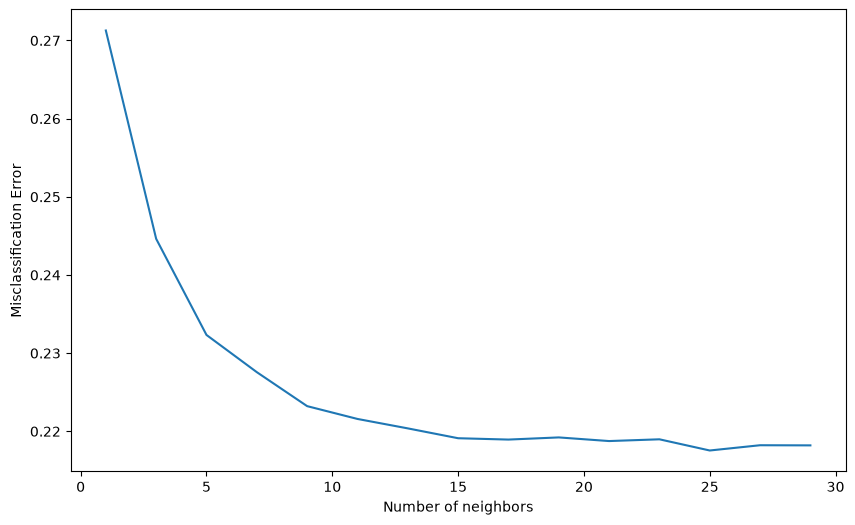

In [530]:
MSE = [1-x for x in cv_scores]

# determining the best k 
optimal_k = neighbors[MSE.index(min(MSE))] 
print('The optimal number of neighbors is % d ' % optimal_k) 
 
plt.figure(figsize = (10, 6)) 
plt.plot(neighbors, MSE) 
plt.xlabel('Number of neighbors') 
plt.ylabel('Misclassification Error') 
plt.show()

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
همانطور که در نمودار دیده می‌شود از جایی به بعد با زیاد شدن مقدار k نمودار تغییر چندانی در مقدار accuracy ندارد. در نتیجه با قراردهی مقداری مانند عدد ۱۵ می‌توان به جواب مناسبی دست پیدا کرد.

</p>
</font>
</div>
</font>

In [531]:
knn = KNeighborsClassifier(n_neighbors = 15) 
knn.fit(x_train_scaled, y_train_balanced) 
y_pred_knn = knn.predict(x_test_scaled)

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
پیاده‌سازی SVM

</p>
</font>
</div>
</font>

In [532]:
svm_model = SVC(verbose=True, max_iter=10000, kernel='linear', degree=1, random_state= 5)
svm_model.fit(x_train_scaled, y_train_balanced)

y_pred_svm = svm_model.predict(x_test_scaled)

[LibSVM]

d:\my_codes\dm-project-2\myvenv\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


<font face="B Mitra">
<div dir=rtl>
<font size=5>
<b> بررسی معیارهای ارزیابی و مقایسه علمکرد مدل‌ها </b>
<br>
</div>
</font>

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
بررسی عملکرد Decision Tree

</p>
</font>
</div>
</font>

Accuracy: 0.7146
Precision: 0.4164046121593291
Recall: 0.717057761732852
F1: 0.5268567639257294
              precision    recall  f1-score   support

         0.0       0.90      0.71      0.80      7784
         1.0       0.42      0.72      0.53      2216

    accuracy                           0.71     10000
   macro avg       0.66      0.72      0.66     10000
weighted avg       0.79      0.71      0.74     10000

Axes(0.125,0.11;0.62x0.77)


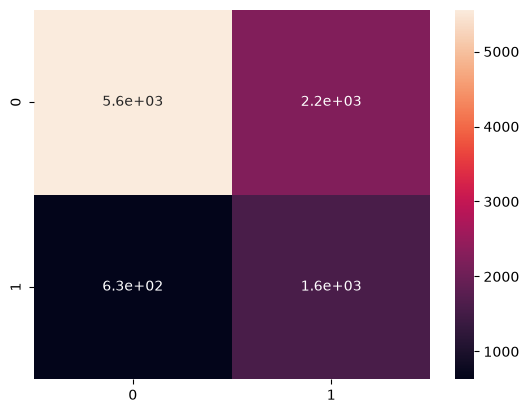

In [533]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print('Accuracy:', acc_dt)
print('Precision:',prec_dt)
print('Recall:', recall_dt)
print('F1:', f1_dt)
print(classification_report(y_test, y_pred_dt))
print(sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True))

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
بررسی عملکرد KNN

</p>
</font>
</div>
</font>

Accuracy: 0.7909
Precision: 0.5190027363940407
Recall: 0.7703068592057761
F1: 0.6201634877384197
              precision    recall  f1-score   support

         0.0       0.92      0.80      0.86      7784
         1.0       0.52      0.77      0.62      2216

    accuracy                           0.79     10000
   macro avg       0.72      0.78      0.74     10000
weighted avg       0.83      0.79      0.80     10000

Axes(0.125,0.11;0.62x0.77)


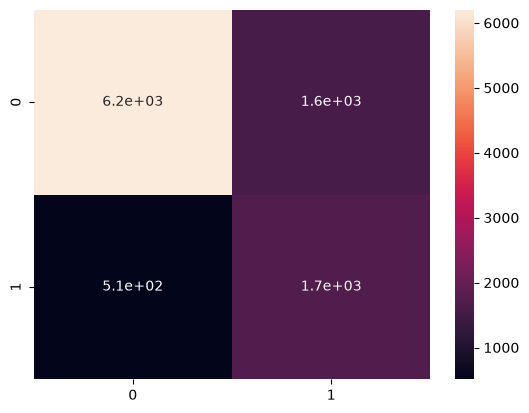

In [534]:
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print('Accuracy:', acc_knn)
print('Precision:',prec_knn)
print('Recall:', recall_knn)
print('F1:', f1_knn)
print(classification_report(y_test, y_pred_knn))
print(sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True))

<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
بررسی عملکرد SVM

</p>
</font>
</div>
</font>

Accuracy: 0.481
Precision: 0.2440619621342513
Recall: 0.6398916967509025
F1: 0.35335160727635184
              precision    recall  f1-score   support

         0.0       0.81      0.44      0.57      7784
         1.0       0.24      0.64      0.35      2216

    accuracy                           0.48     10000
   macro avg       0.53      0.54      0.46     10000
weighted avg       0.68      0.48      0.52     10000

Axes(0.125,0.11;0.62x0.77)


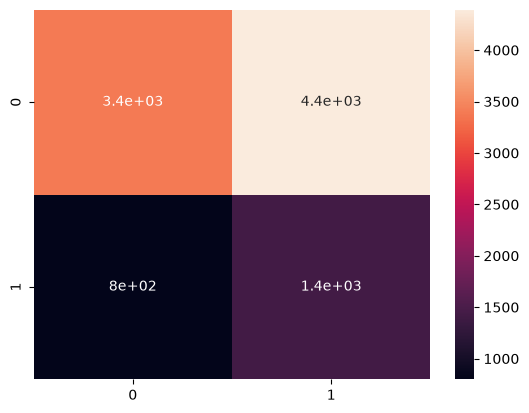

In [535]:
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print('Accuracy:', acc_svm)
print('Precision:',prec_svm)
print('Recall:', recall_svm)
print('F1:', f1_svm)
print(classification_report(y_test, y_pred_svm))
print(sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True))

<font face="B Mitra">
<div dir=rtl>
<font size=5>
<b> نتیجه‌گیری </b>
<br>
</div>
</font>

In [536]:
myTable = PrettyTable(["Method", "Accuracy", "Precision", "recall", "f1_score"]) 

myTable.add_row(["Decision Tree", acc_dt, prec_dt, recall_dt, f1_dt])
myTable.add_row(["KNN", acc_knn, prec_dt, recall_knn, f1_knn])
myTable.add_row(["SVM", acc_svm, prec_svm, recall_svm, f1_svm])

print(myTable)

+---------------+----------+--------------------+--------------------+---------------------+
|     Method    | Accuracy |     Precision      |       recall       |       f1_score      |
+---------------+----------+--------------------+--------------------+---------------------+
| Decision Tree |  0.7146  | 0.4164046121593291 | 0.717057761732852  |  0.5268567639257294 |
|      KNN      |  0.7909  | 0.4164046121593291 | 0.7703068592057761 |  0.6201634877384197 |
|      SVM      |  0.481   | 0.2440619621342513 | 0.6398916967509025 | 0.35335160727635184 |
+---------------+----------+--------------------+--------------------+---------------------+


<font face="B Mitra">
<div dir=rtl>
<p align="justify">
<font size=5>
در این پروژه هدف ما پیش‌بینی وقوع بارش در روز آینده بود. 
<br>
به طور کلی مدل  KNN پیش‌بینی بهتری نسبت به سایر مدل‌ها داشته است و f1 بهتری هم کسب کرده است.
<br>
مدل Decision Tree هم با توجه به داشتن recall بالا در تشخیص روز‌های بارانی خوب عمل می‌کند.
<br>
مدل SVM با توجه به داشتن کمترین Precision بیشترین خطا را در تشخیص روز‌های بارانی دارد. (روز‌های غیر بارانی بیشتری را به عنوان روز بارانی اعلام می‌کند !)

</p>
</font>
</div>
</font>